# Computing the dynamic ZDR calibration using Kriging

This notebook implements Ordinary Kriging on pre-processed ZDR data (from vertical PPI scans) to compute the dynamic ZDR calibration.\
It requires to have previously run the **01_compute_filtered_dataframe.out** notebook to generate the pre-processed ZDR data.


*NC: this notebook was run on 03.07.2026 for final calculation of Zdr-correction for the CHOPIN campaign.*

In [32]:
import os
import glob
import vaex
import scipy
import copy
import pickle
import datetime
import numpy as np
import colorcet as cc
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
from matplotlib import rc

from pykrige.ok import OrdinaryKriging
#from skgstat import Variogram
from matplotlib.ticker import MultipleLocator, FuncFormatter
from datetime import datetime, timezone, timedelta

In [33]:
# IN_DIR = 'dataframes_v5'
IN_DIR = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606/'
campaign_name = 'CHOPIN_2024'

In [34]:
# Loading the filtered dictionary
in_corr_fname = 'dataframe_filtered_v2_median_derivative_%s.hdf5' % campaign_name
filtered_df = vaex.open(os.path.join(IN_DIR, in_corr_fname))

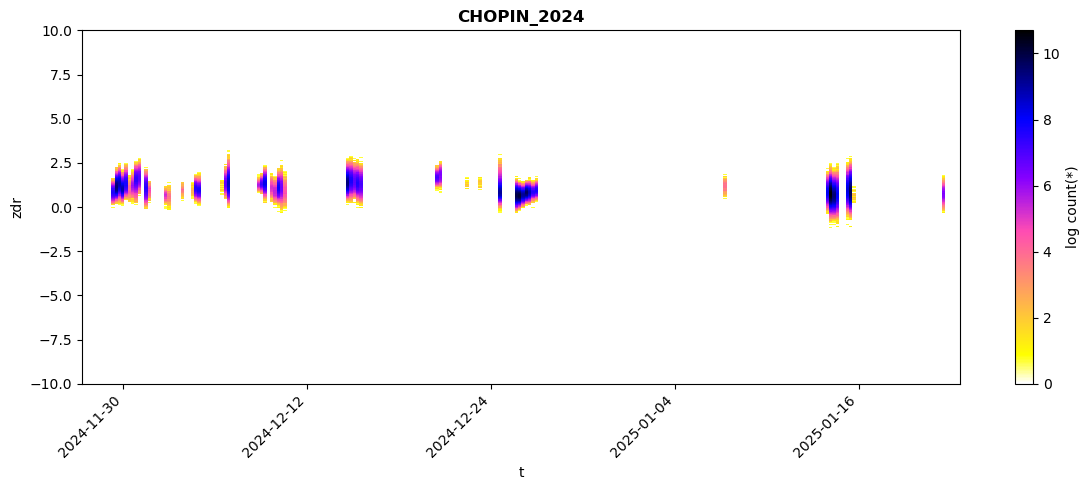

In [35]:
savefig = True

fig, ax = plt.subplots(1, 1, figsize=[12, 5])

filtered_df.viz.heatmap(filtered_df.t, filtered_df.zdr, f='log', colormap='gnuplot2_r')
ax.set_ylim([-10, 10])

t_dt = pd.to_datetime(filtered_df.t.to_numpy(), unit='s')
start = t_dt.min() - pd.Timedelta(days=1)
end = t_dt.max() + pd.Timedelta(days=1)
start_unix = start.timestamp()
end_unix = end.timestamp()

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(pd.to_datetime(ax.get_xticks(), unit='s').strftime('%Y-%m-%d'), rotation=45, ha='right')
ax.set_xlim([start_unix, end_unix])
plt.title(campaign_name, fontweight='bold')
plt.ylim(-10,10)
plt.tight_layout()

if savefig: 
    out_fig_fname = f'{IN_DIR}/filtered_heatmap_{campaign_name}.pdf'
    plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

## Computing some stats in function of time

In [36]:

t_array = filtered_df['t'].to_numpy()
zdr_array = filtered_df['zdr'].to_numpy()

unique_t = np.unique(t_array)
num_valid = np.zeros(unique_t.shape)

q05_zdr = np.zeros(unique_t.shape)
q25_zdr = np.zeros(unique_t.shape)
med_zdr = np.zeros(unique_t.shape)
q75_zdr = np.zeros(unique_t.shape)
q95_zdr = np.zeros(unique_t.shape)

for i_t, curr_t in enumerate(unique_t):
    valid_t = t_array == curr_t

    curr_zdr_array = zdr_array[valid_t]
    num_valid[i_t] = np.sum(np.isfinite(curr_zdr_array))

    q05_zdr[i_t] = np.nanquantile(curr_zdr_array, q=0.05)
    q25_zdr[i_t] = np.nanquantile(curr_zdr_array, q=0.25)
    med_zdr[i_t] = np.nanmedian(curr_zdr_array)
    q75_zdr[i_t] = np.nanquantile(curr_zdr_array, q=0.75)
    q95_zdr[i_t] = np.nanquantile(curr_zdr_array, q=0.95)
    
curr_dic = {}
    
curr_dic['unique_t'] = unique_t
curr_dic['num_valid'] = num_valid
curr_dic['q05_zdr'] = q05_zdr
curr_dic['q25_zdr'] = q25_zdr
curr_dic['med_zdr'] = med_zdr
curr_dic['q75_zdr'] = q75_zdr
curr_dic['q95_zdr'] = q95_zdr

campaign_stat_dic = curr_dic

###  Addition: check on num of scans in last hour and last day

In [8]:
old_campaign_stat_dic = copy.deepcopy(campaign_stat_dic)

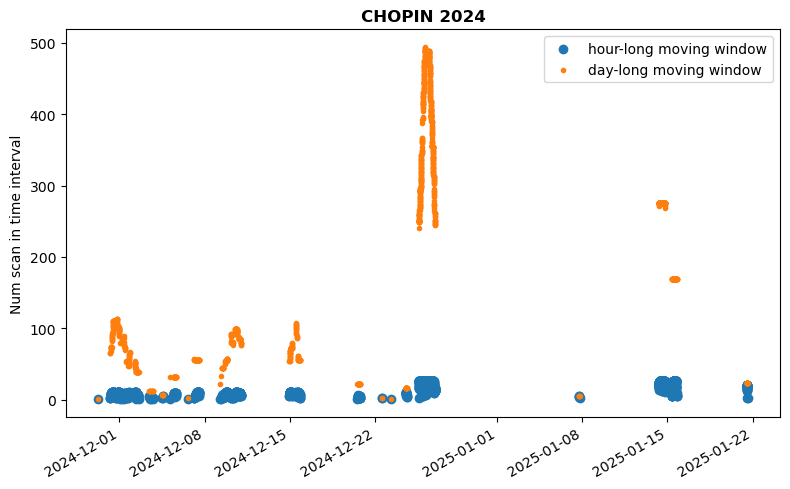

In [37]:
savefig = False

window1 = 3600.
window2 = 3600. * 24.

half_window1 = window1 / 2.
half_window2 = window2 / 2.

datetimes = [pd.to_datetime(i, unit='s') for i in campaign_stat_dic['unique_t']]

count_window1 = np.zeros(old_campaign_stat_dic['unique_t'].shape)
count_window2 = np.zeros(old_campaign_stat_dic['unique_t'].shape)

for i_t, t in enumerate(old_campaign_stat_dic['unique_t']):
    count_window1[i_t] = np.sum(np.logical_and(old_campaign_stat_dic['unique_t'] >= t - half_window1,
                                                old_campaign_stat_dic['unique_t'] <= t + half_window1))
    count_window2[i_t] = np.sum(np.logical_and(old_campaign_stat_dic['unique_t'] >= t - half_window2,
                                                old_campaign_stat_dic['unique_t'] <= t + half_window2))

campaign_stat_dic['count_window1'] = count_window1
campaign_stat_dic['count_window2'] = count_window2

old_campaign_stat_dic['count_window1'] = count_window1
old_campaign_stat_dic['count_window2'] = count_window2

fig, ax = plt.subplots(1, 1, figsize=[8, 5])

ax.scatter(datetimes, campaign_stat_dic['count_window1'], marker='o', label='hour-long moving window')
ax.scatter(datetimes, campaign_stat_dic['count_window2'], marker='.', label='day-long moving window')
#ax.set_yscale('log')


# Format x-axis to show human-readable dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

fig.autofmt_xdate()  # Rotate and align date labels

ax.set_ylabel('Num scan in time interval')

ax.set_title(campaign_name.replace('_', ' '), fontweight='bold')
plt.legend()
plt.tight_layout()

if savefig:
    out_fig_fname = f'{IN_DIR}/filtered_heatmap_{campaign_name}.pdf'
    plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

### Going back to normal processing adding the extra check

In [38]:
MIN_NUM_COUNT = 100
# Filtering stat dic

valid_count_window1 = campaign_stat_dic['count_window1'] >= 3
valid_count_window2 = campaign_stat_dic['count_window2'] >= 10
valid_count_window = np.logical_and(valid_count_window1, valid_count_window2)
valid =np.logical_and(campaign_stat_dic['num_valid'] > MIN_NUM_COUNT,
                        valid_count_window)

filtered_dic = {}
for k in campaign_stat_dic.keys():
    filtered_dic[k] = campaign_stat_dic[k][valid]
    
campaign_stat_dic = filtered_dic

In [39]:
num_valid = np.zeros(filtered_df['t'].to_numpy().shape)
count_win1 = np.zeros(filtered_df['t'].to_numpy().shape)
count_win2 = np.zeros(filtered_df['t'].to_numpy().shape)

for i_t, t in enumerate(filtered_dic['unique_t']):
    curr_t = filtered_df['t'].to_numpy() == t
    num_valid[curr_t] = filtered_dic['num_valid'][i_t]
    count_win1[curr_t] = filtered_dic['count_window1'][i_t]
    count_win2[curr_t] = filtered_dic['count_window2'][i_t]
    
filtered_df['num_valid'] = num_valid
filtered_df['count_window1'] = count_win1
filtered_df['count_window2'] = count_win2

In [40]:
print(np.nanmedian(old_campaign_stat_dic['med_zdr']))
print(np.nanmedian(campaign_stat_dic['med_zdr']))

0.8112376928329468
0.808039128780365


In [59]:
print(np.nanmean(old_campaign_stat_dic['med_zdr']))
print(np.nanmean(campaign_stat_dic['med_zdr']))

0.9073174420276634
0.9080120074624539


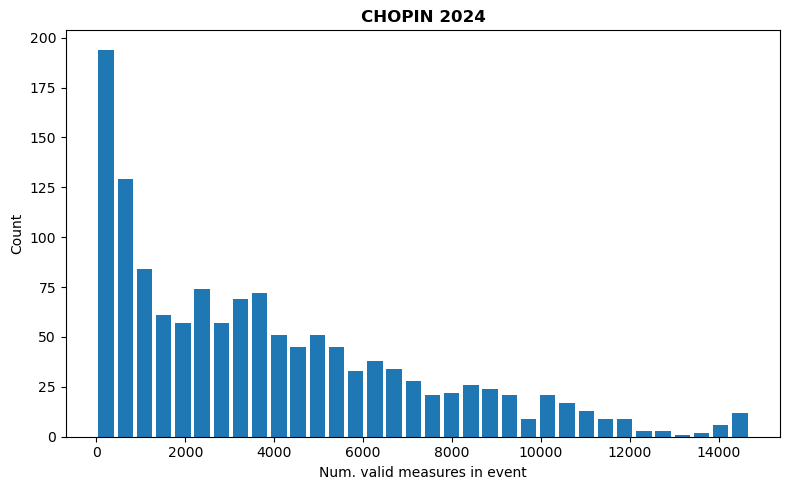

In [41]:
savefig = True

fig, ax = plt.subplots(1,1, figsize=[8, 5])

num_valid = campaign_stat_dic['num_valid']

#print(np.sum(num_valid < 10))

ax.hist(num_valid[num_valid <= 100], bins=np.linspace(0, num_valid.max(), 35),
        rwidth=0.8, color='tab:red')
ax.hist(num_valid[num_valid > 100], bins=np.linspace(0, num_valid.max(), 35),
        rwidth=0.8, color='tab:blue')
ax.set_title(campaign_name.replace('_', ' '), fontweight='bold')
ax.set_xlabel('Num. valid measures in event')
ax.set_ylabel('Count')

plt.tight_layout()

if savefig:
        out_fig_fname = f'{IN_DIR}/filtered_count_validmeasures_{campaign_name}.pdf'
        plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

## Variogram

In [42]:
def compute_variogram(x, y, nbins=10, max_time_diff=None):
    '''
    Attention: x must be sorted
    
    y in minutes
    max_time_diff in minutes
    '''
    x_mat = np.tile(x, (x.shape[0], 1))
    distance_matrix = x_mat - x_mat.T
    
    y_mat = np.tile(y, (y.shape[0], 1))
    square_diff_matrix = np.square(y_mat - y_mat.T)
    
    if not max_time_diff:
        accepted_diff = distance_matrix > 0
    else:
        accepted_diff = np.logical_and(distance_matrix > 0,
                                       distance_matrix <= max_time_diff)
    
    distance_array = distance_matrix[accepted_diff].flatten()
    square_diff_array = square_diff_matrix[accepted_diff].flatten()
    
    bins = np.linspace(distance_array.min(), distance_array.max(), nbins)
    sample_variogram = np.zeros(bins.shape[0]-1, dtype='float32')
    bin_centers = np.zeros(bins.shape[0]-1, dtype='float32')
    num_points = np.zeros(bins.shape[0]-1, dtype='float32')
    
    for i_b, b in enumerate(bins[1:]):
        accepted_bin = np.logical_and(np.logical_and(distance_array >= bins[i_b - 1],
                                                     distance_array < b),
                                      np.isfinite(distance_array))
        sample_variogram[i_b] = np.nanmean(square_diff_array[accepted_bin])
        bin_centers[i_b] = np.nanmean(distance_array[accepted_bin])
        num_points[i_b] = np.sum(accepted_bin)
    
    sample_variogram = sample_variogram
    bin_centers = bin_centers
    num_points = num_points

    sample_variogram /= 2.
    
    return bin_centers, bins, sample_variogram, num_points

### Computing variogram - need to define nbin and max_time_diff for the campaign

In [43]:
unique_t = campaign_stat_dic['unique_t']
med_zdr = campaign_stat_dic['med_zdr']

first_PPI90 = datetime.fromtimestamp(int(campaign_stat_dic['unique_t'][0]),tz=timezone.utc)
t0 = (first_PPI90 - timedelta(days=365)).replace(tzinfo=timezone.utc).timestamp()

# Deciding a num of bins in order to keep the count histogram with no periodic spikes
if campaign_name == 'HYMEX_2013':
    nbin = 112
    max_time_diff = 60.*8.
if campaign_name == 'PAYERNE_2014':
    nbin = 112
    max_time_diff = 60.*8.
if campaign_name == 'DAVOS_2014':
    nbin = 59
    max_time_diff = 60.*6.
if campaign_name == 'VALAIS_2016_1':
    nbin = 40
    max_time_diff = 90.
if campaign_name == 'VALAIS_2016_2':
    nbin =  157
    max_time_diff = 60.*14.
if campaign_name == 'APRES3_1':
    nbin = 133 # 90
    max_time_diff = 60.*12. # 8
if campaign_name == 'APRES3_2':
    nbin = 133
    max_time_diff = 60.*12
if campaign_name == 'PLATO_2019':
    nbin = 91
    max_time_diff = 60.*8.
if campaign_name == 'ICEGENESIS_2021':
#         nbin = 93#108 #110 113 -> considering first part of variogram only
#         max_time_diff = 60.*5
    nbin = 59
    max_time_diff = 60.*14
if campaign_name == 'CHOPIN_2024':
    nbin = 59
    max_time_diff = 60.*10.
    
bins_all, bin_edges, sample_variogram_all, num_points_all = compute_variogram((unique_t-t0)/60.,
                                                                        med_zdr,
                                                                        nbins=nbin, #100,
                                                                        max_time_diff=max_time_diff)  

full_campaign_variogram_dic = {'t0':t0,
            'bins':bins_all,
            'bin_edges':bin_edges,
            'sample_variogram':sample_variogram_all,
            'num_points':num_points_all}

/tmp/ipykernel_1028428/1455143168.py:32: RuntimeWarning: Mean of empty slice
  sample_variogram[i_b] = np.nanmean(square_diff_array[accepted_bin])
/tmp/ipykernel_1028428/1455143168.py:33: RuntimeWarning: Mean of empty slice
  bin_centers[i_b] = np.nanmean(distance_array[accepted_bin])


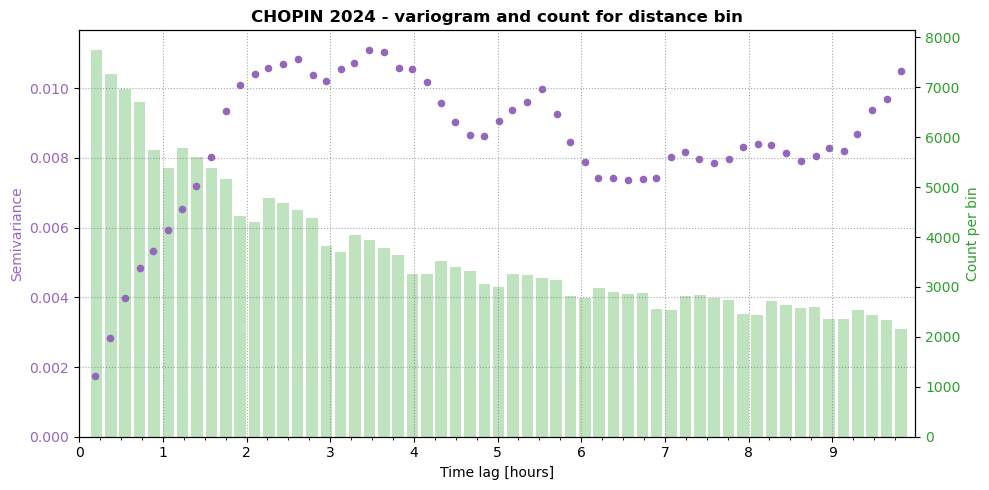

In [44]:
savefig = True

fig, ax = plt.subplots(1, 1, figsize=[10,5])

color1 = 'tab:purple'
color2 = 'tab:green'

unique_t = campaign_stat_dic['unique_t']
med_zdr = campaign_stat_dic['med_zdr']

bins_all = full_campaign_variogram_dic['bins']
bin_edges = full_campaign_variogram_dic['bin_edges']
sample_variogram_all = full_campaign_variogram_dic['sample_variogram']
num_points_all = full_campaign_variogram_dic['num_points']

marker_size = 20.
bar_width = 0.8
    
ax.scatter(bins_all, sample_variogram_all,
        s=marker_size, color=color1)

ax_twin = ax.twinx()
ax_twin.bar(bin_edges[:-1], num_points_all, width=bar_width*np.diff(bin_edges), align='center',
            color=color2, alpha=0.3, zorder=1)

ax.set_zorder(ax_twin.get_zorder()+1)
ax.patch.set_visible(False)

ax.grid(ls=':', c='gray', alpha=0.7)

ax.set_title('%s - variogram and count for distance bin' % campaign_name.replace('_', ' '), fontweight='bold')

ax.set_ylabel('Semivariance', color=color1)
ax_twin.set_ylabel('Count per bin', color=color2)

ax.tick_params(axis='y', labelcolor=color1)
ax_twin.tick_params(axis='y', labelcolor=color2)

ax.set_ylim((0., np.nanmax(sample_variogram_all)*1.05))

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/60:.0f}"))
ax.set_xlabel('Time lag [hours]')

if campaign_name == 'APRES3_2':
    ax.set_xlim((0., 60.*12.))
    ax.xaxis.set_major_locator(MultipleLocator(60))
    ax.xaxis.set_minor_locator(MultipleLocator(15))
elif campaign_name == 'VALAIS_2016_1':
    ax.set_xlim((0., 90.))
    ax.xaxis.set_major_locator(MultipleLocator(15))
    ax.xaxis.set_minor_locator(MultipleLocator(5))
elif campaign_name == 'VALAIS_2016_2':
    ax.set_xlim((0., 60.*14.))
    ax.xaxis.set_major_locator(MultipleLocator(60))
    ax.xaxis.set_minor_locator(MultipleLocator(15))
elif campaign_name == 'DAVOS_2014':
    ax.set_xlim((0., 60.*6.))
    ax.xaxis.set_major_locator(MultipleLocator(60))
    ax.xaxis.set_minor_locator(MultipleLocator(15))
else:
    ax.set_xlim((0., max(bin_edges)))
    ax.xaxis.set_major_locator(MultipleLocator(60))
    ax.xaxis.set_minor_locator(MultipleLocator(15))

plt.tight_layout()

if savefig:
    out_fig_fname = f'{IN_DIR}/variogram_raw_{campaign_name}.pdf'
    plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

## Variogram fit

In [19]:
# Variogram models defined as the way preferred by pykrige
def spherical_variogram(parameters, x):
    [rng, par_sill, nugget] = parameters
    fitted_variogram = nugget + par_sill * ((1.5 * x/rng) - (0.5 * np.power(x/rng, 3)))
    fitted_variogram[x > rng] = nugget + par_sill
    return fitted_variogram

def two_sperical_variogram(parameters, x):
    [rng1, par_sill1, rng2, par_sill2, nugget] = parameters
    fitted_variogram = nugget + par_sill1 * ((1.5 * x/rng1) - (0.5 * np.power(x/rng1, 3)))
    fitted_variogram[x > rng1] = nugget + par_sill1
    
    fitted_variogram += par_sill2 * ((1.5 * x/rng2) - (0.5 * np.power(x/rng2, 3)))
    fitted_variogram[x > rng2] = nugget + par_sill1 + par_sill2
    return fitted_variogram

def gaussian_variogram(parameters, x):
    [rng, par_sill, nugget] = parameters
    a = rng / 1.7
    fitted_variogram = nugget + par_sill * (1. - np.exp(-np.square(x/a)))
    return fitted_variogram

def spherical_plus_gaussian_variogram(parameters, x):
    [rng_sph, par_sill_sph, rng_gau, par_sill_gau, nugget] = parameters
    fitted_variogram = nugget + par_sill_sph * ((1.5 * x/rng_sph) - (0.5 * np.power(x/rng_sph, 3)))
    fitted_variogram[x > rng_sph] = nugget + par_sill_sph
    
    a = rng_gau / 1.7
    fitted_variogram += par_sill_gau * (1. - np.exp(-np.square(x/a)))
    
    return fitted_variogram

def two_spherical_plus_gaussian_variogram(parameters, x):
    [rng_sph1, par_sill_sph1, rng_sph2, par_sill_sph2, rng_gau, par_sill_gau, nugget] = parameters
    fitted_variogram = nugget + par_sill_sph1 * ((1.5 * x/rng_sph1) - (0.5 * np.power(x/rng_sph1, 3)))
    fitted_variogram[x > rng_sph1] = nugget + par_sill_sph1
    
    fitted_variogram += par_sill_sph2 * ((1.5 * x/rng_sph2) - (0.5 * np.power(x/rng_sph2, 3)))
    fitted_variogram[x > rng_sph2] += par_sill_sph2
    
    a = rng_gau / 1.7
    fitted_variogram += par_sill_gau * (1. - np.exp(-np.square(x/a)))
    
    return fitted_variogram

def spherical_plus_exponential_variogram(parameters, x):
    [rng_sph, par_sill_sph, rng_exp, par_sill_exp, nugget] = parameters
    fitted_variogram = nugget + par_sill_sph * ((1.5 * x/rng_sph) - (0.5 * np.power(x/rng_sph, 3)))
    fitted_variogram[x > rng_sph] = nugget + par_sill_sph
    
    a = rng_exp / 3.
    fitted_variogram += par_sill_exp * (1. - np.exp(-x/a))
    
    return fitted_variogram

def exponential_variogram(parameters, x):
    [rng, par_sill, nugget] = parameters
    a = rng / 3.
    fitted_variogram = nugget + par_sill * (1. - np.exp(-x/a))
    return fitted_variogram

def exponential_plus_gaussian_variogram(parameters, x):
    [rng_exp, par_sill_exp, rng_gau, par_sill_gau, nugget] = parameters
    
    a_exp = rng_exp / 3.
    fitted_variogram = nugget + par_sill_exp * (1. - np.exp(-x/a_exp))
    
    a_gau = rng_gau / 1.7
    fitted_variogram += par_sill_gau * (1. - np.exp(-np.square(x/a_gau)))
    
    return fitted_variogram

def exponential_plus_spherical_variogram(parameters, x):
    [rng_exp, par_sill_exp, rng_sph, par_sill_sph, nugget] = parameters
    
    a_exp = rng_exp / 3.
    fitted_variogram = nugget + par_sill_exp * (1. - np.exp(-x/a_exp))
    
    fitted_variogram[x <= rng_sph] += par_sill_sph * ((1.5 * x[x<=rng_sph]/rng_sph) - 
                                                      (0.5 * np.power(x[x<=rng_sph]/rng_sph, 3)))
    fitted_variogram[x > rng_sph] += par_sill_sph
    
    return fitted_variogram

def pure_nugget_variogram(parameters, x):
    [nugget] = parameters
    fitted_variogram = np.ones(x.shape)*nugget
    return fitted_variogram

# Redefinition as scipy standard
def spherical_variogram_scipy(x, rng, sill, nugget):
    parameters = [rng, sill, nugget]
    return spherical_variogram(parameters, x)

def two_sperical_variogram_scipy(x, rng1, sill1, rng2, sill2, nugget):
    parameters = [rng1, sill1, rng2, sill2, nugget]
    return two_sperical_variogram(parameters, x)

def gaussian_variogram_scipy(x, rng, sill, nugget):
    parameters = [rng, sill, nugget]
    return gaussian_variogram(parameters, x)

def spherical_plus_gaussian_variogram_scipy(x, rng_sph, sill_sph, rng_gau, sill_gau, nugget):
    parameters = [rng_sph, sill_sph, rng_gau, sill_gau, nugget]
    return spherical_plus_gaussian_variogram(parameters, x)

def two_spherical_plus_gaussian_variogram_scipy(x, rng_sph1, sill_sph1, rng_sph2, sill_sph2, rng_gau, sill_gau, nugget):
    parameters = [rng_sph1, sill_sph1, rng_sph2, sill_sph2, rng_gau, sill_gau, nugget]
    return two_spherical_plus_gaussian_variogram(parameters, x)

def spherical_plus_exponential_variogram_scipy(x, rng_sph, sill_sph, rng_exp, sill_exp, nugget):
    parameters = [rng_sph, sill_sph, rng_exp, sill_exp, nugget]
    return spherical_plus_exponential_variogram(parameters, x)

def exponential_variogram_scipy(x, rng, sill, nugget):
    parameters = [rng, sill, nugget]
    return exponential_variogram(parameters, x)

def exponential_plus_gaussian_variogram_scipy(x, rng_exp, sill_exp, rng_gau, sill_gau, nugget):
    parameters = [rng_exp, sill_exp, rng_gau, sill_gau, nugget]
    return exponential_plus_gaussian_variogram(parameters, x)

def exponential_plus_spherical_variogram_scipy(x, rng_exp, sill_exp, rng_sph, sill_sph, nugget):
    parameters = [rng_exp, sill_exp, rng_sph, sill_sph, nugget]
    return exponential_plus_spherical_variogram(parameters, x)

def pure_nugget_variogram_scipy(x, nugget):
    parameters = [nugget]
    return pure_nugget_variogram(parameters, x)

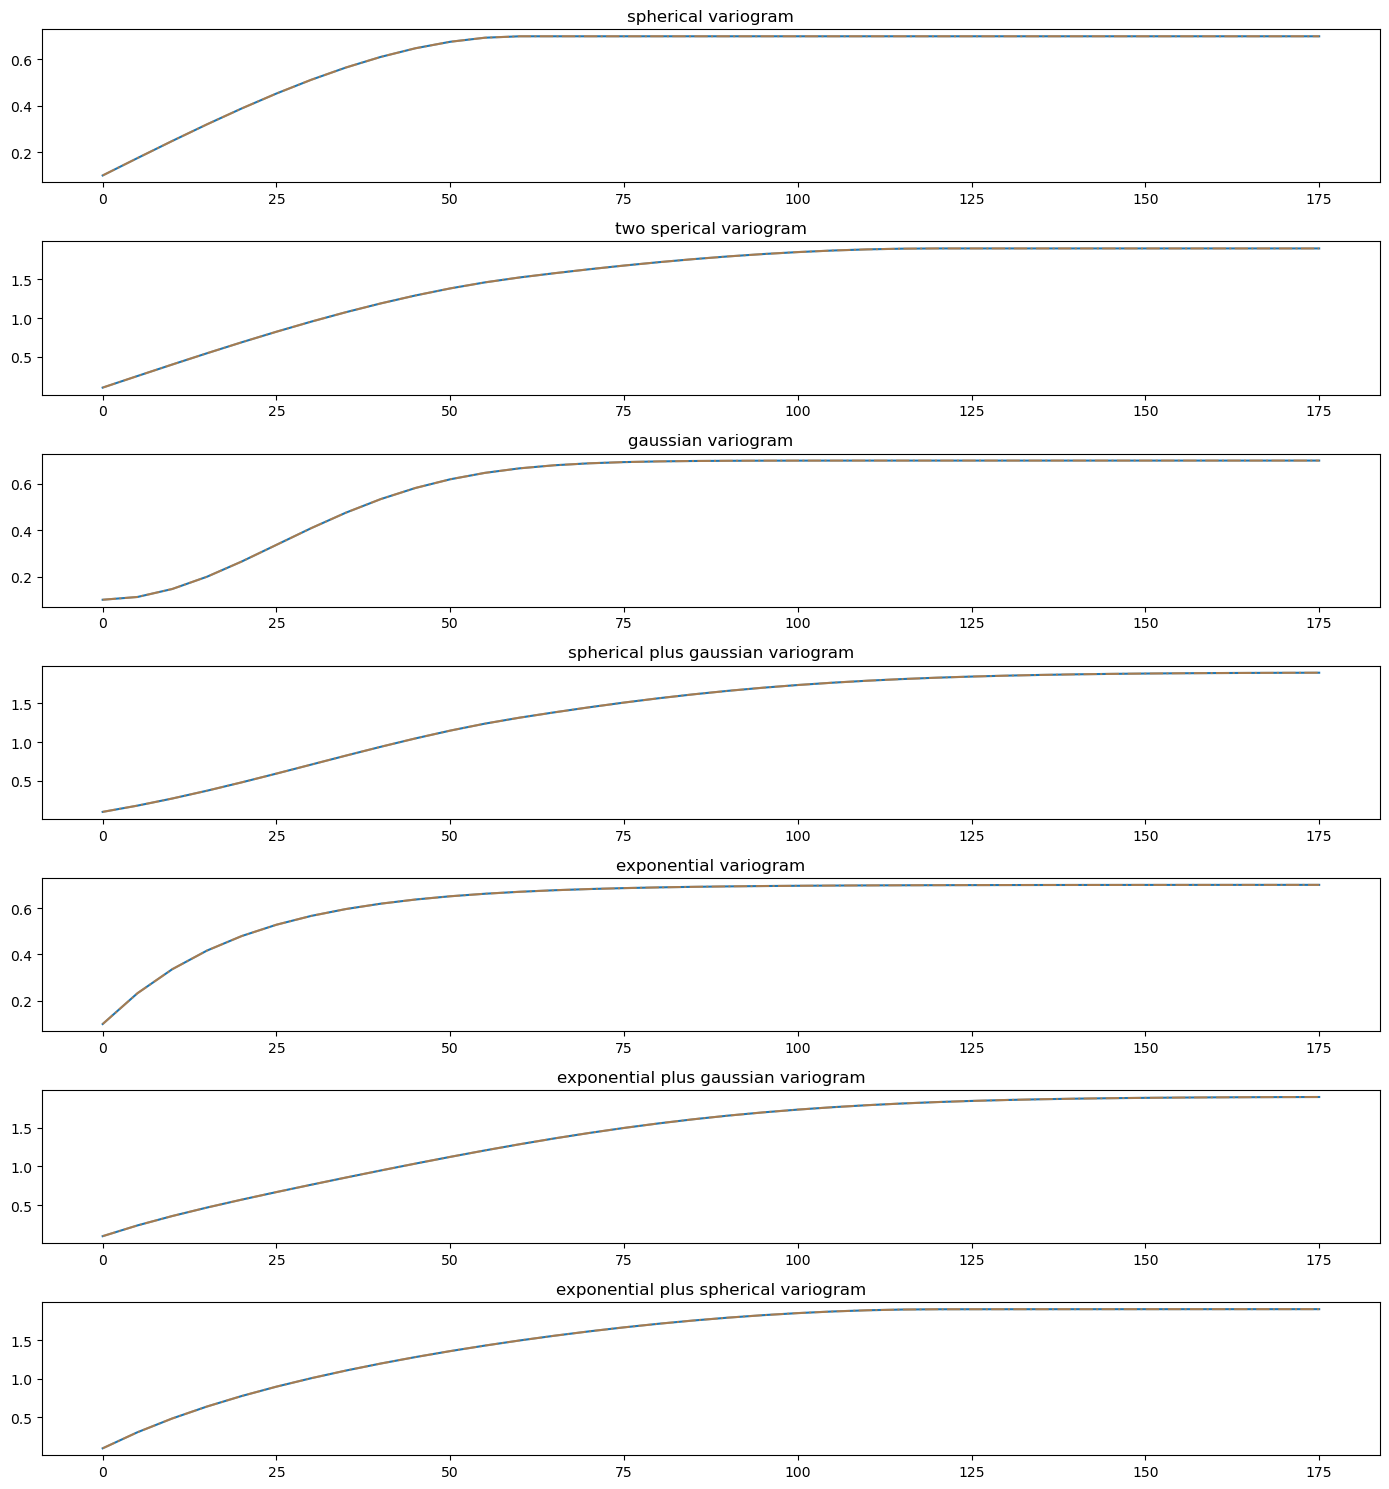

In [20]:
# Plotting variograms to check
fig, axes = plt.subplots(7, 1, figsize=[14, 15])

x=np.arange(0, 180, 5)

axes[0].set_title('spherical variogram')
axes[0].plot(x, spherical_variogram([60, 0.6, 0.1], x))
axes[0].plot(x, spherical_variogram_scipy(x, 60, 0.6, 0.1), ls='-.', alpha=0.6)

axes[1].set_title('two sperical variogram')
axes[1].plot(x, two_sperical_variogram([60, 0.6, 120, 1.2, 0.1], x))
axes[1].plot(x, two_sperical_variogram_scipy(x, 60, 0.6, 120, 1.2, 0.1), ls='-.', alpha=0.6)

axes[2].set_title('gaussian variogram')
axes[2].plot(x, gaussian_variogram([60, 0.6, 0.1], x))
axes[2].plot(x, gaussian_variogram_scipy(x, 60, 0.6, 0.1), ls='-.', alpha=0.6)

axes[3].set_title('spherical plus gaussian variogram')
axes[3].plot(x, spherical_plus_gaussian_variogram([60, 0.6, 120, 1.2, 0.1], x))
axes[3].plot(x, spherical_plus_gaussian_variogram_scipy(x, 60, 0.6, 120, 1.2, 0.1), ls='-.', alpha=0.6)

axes[4].set_title('exponential variogram')
axes[4].plot(x, exponential_variogram([60, 0.6, 0.1], x))
axes[4].plot(x, exponential_variogram_scipy(x, 60, 0.6, 0.1), ls='-.', alpha=0.6)

axes[5].set_title('exponential plus gaussian variogram')
axes[5].plot(x, exponential_plus_gaussian_variogram([60, 0.6, 120, 1.2, 0.1], x))
axes[5].plot(x, exponential_plus_gaussian_variogram_scipy(x, 60, 0.6, 120, 1.2, 0.1), ls='-.', alpha=0.6)

axes[6].set_title('exponential plus spherical variogram')
axes[6].plot(x, exponential_plus_spherical_variogram([60, 0.6, 120, 1.2, 0.1], x))
axes[6].plot(x, exponential_plus_spherical_variogram_scipy(x, 60, 0.6, 120, 1.2, 0.1), ls='-.', alpha=0.6)

plt.tight_layout()

### Fitting the variogram - need to adjust the starting point and variogram shape for each campaign, depending on the empirical variogram plot

In [45]:
# Fitting the variogram with scipy
if campaign_name == 'HYMEX_2013':
    f = spherical_plus_gaussian_variogram_scipy # two_sperical_variogram_scipy

    rng_0 = 30.
    sill_0 = 0.003
    rng_1 = 300.
    sill_1 = 0.008
    nugget0 = 0.001
    p0 = [rng_0, sill_0, rng_0, sill_0, nugget0]

    max_x = 420.
    bounds = ([27., 0.0022, rng_0, sill_0, 0.], [rng_1, np.inf, max_x, np.inf, sill_0 + nugget0])
elif campaign_name == 'PAYERNE_2014':
    f = two_sperical_variogram_scipy # spherical_plus_gaussian_variogram_scipy

    rng_0 = 30.
    sill_0 = 0.002
    rng_1 = 290.
    sill_1 = 0.005
    nugget0 = 0.0002
    p0 = [rng_0, sill_0, rng_1, sill_1, nugget0]

    max_x = 420.
    bounds = ([0., 0., rng_0, sill_0, 0.], [rng_1, 0.005, max_x, np.inf, sill_0 + nugget0])
elif campaign_name == 'DAVOS_2014':
    f = spherical_variogram_scipy

    rng0 = 180.
    sill0 = 0.008
    nugget0 = 0.001
    p0 = [rng0, sill0, nugget0]

    max_x = 300.
    bounds = ([0., nugget0, 0.], [max_x, np.inf, sill0])
elif campaign_name == 'VALAIS_2016_2':
    f = spherical_variogram_scipy

    rng0 = 660.
    sill0 = 0.024
    nugget0 =0.001
    p0 = [rng0, sill0, nugget0]

    max_x = 800.
    bounds = ([0., nugget0, 0.], [max_x, np.inf, sill0])
elif campaign_name == 'APRES3_1':
    f = spherical_plus_gaussian_variogram_scipy #exponential_plus_gaussian_variogram_scipy

    rng_0 = 110.
    sill_0 = 0.005
    rng_1 = 600.
    sill_1 = 0.009
    nugget0 = 0.001
    p0 = [rng_0, sill_0, rng_0, sill_0, nugget0]

    max_x = 720.
    bounds = ([0., 0., rng_0, sill_0, 0.], [130., np.inf, max_x, np.inf, np.inf])
elif campaign_name == 'APRES3_2':
    f = gaussian_variogram_scipy

    rng0 = 600.
    sill0 = 0.024
    nugget0 = 0.001
    p0 = [rng0, sill0, nugget0]

    max_x = 720.
    bounds = ([0., nugget0, 0.], [max_x, np.inf, sill0])
    
elif campaign_name == 'PLATO_2019':
    f = spherical_variogram_scipy

    rng0 = 350.
    sill0 = 0.024
    nugget0 =0.001
    p0 = [rng0, sill0, nugget0]

    max_x = 500.
    bounds = ([0., nugget0, 0.], [max_x, np.inf, sill0])
    

elif campaign_name == 'ICEGENESIS_2021':
    f = spherical_plus_gaussian_variogram_scipy #exponential_plus_gaussian_variogram_scipy

    rng_0 = 120.
    sill_0 = 0.015
    rng_1 = 600.
    sill_1 = 0.05
    nugget0 = 0.001
    p0 = [rng_0, sill_0, rng_1, sill_1, nugget0]

    max_x = 720.
    bounds = ([100., 0.01, 500, sill_0, 0.001], [400., 2.5e-2, 800, 0.075, 0.0018])
    

elif campaign_name == 'CHOPIN_2024':
    #f = gaussian_variogram_scipy
    f = spherical_variogram_scipy

    rng0 = 120.
    sill0 = 0.025
    rng1 = 200.
    sill1 = 0.015
    nugget0 = 0.0001
    p0 = [rng0, sill0, nugget0]
    #p0 = [rng0, sill0, rng1, sill1, nugget0]

    max_x = 500.
    bounds = ([0., nugget0, 0.], [max_x, np.inf, sill0]) #spherical / gaussian
    #bounds = ([100., 0.01, 500, sill0, 0.001], [400, 2.5e-2, 800, 0.075, 0.0018]) #spherical+gaussian

    #lower_bounds = [ 50.,  0.005,  50.,  0.005,  0.00001 ]  # [rng0, sill0, rng1, sill1, nugget]
    #upper_bounds = [400., 0.05,  400., 0.05,   0.001  ]  # Allow more freedom in sill and nugget
    #bounds = (lower_bounds, upper_bounds)


bin_center = full_campaign_variogram_dic['bins']
gamma = full_campaign_variogram_dic['sample_variogram']

accepted = bin_center < max_x
bin_center = bin_center[accepted]
gamma = gamma[accepted]
    
popt, pcov = scipy.optimize.curve_fit(f, bin_center, gamma, p0=p0, bounds=bounds)

full_campaign_variogram_fit_dic = {'popt':popt, 'pcov':pcov}

In [46]:
max_time_diff / 60

10.0

In [47]:
full_campaign_variogram_dic

{'t0': 1701410816.0,
 'bins': array([       nan,  11.509182,  22.124483,  32.81222 ,  43.505047,
         53.13476 ,  63.78695 ,  73.38965 ,  84.021034,  94.79933 ,
        105.53055 , 115.08621 , 125.86103 , 135.37328 , 146.08307 ,
        156.74466 , 167.3935  , 176.94089 , 187.6953  , 197.26929 ,
        207.93326 , 218.48668 , 229.26897 , 238.94206 , 249.58456 ,
        259.1146  , 269.7544  , 280.4551  , 290.35635 , 300.79016 ,
        310.59268 , 320.9322  , 331.67694 , 342.29947 , 352.0063  ,
        362.58786 , 372.16095 , 382.81412 , 393.58542 , 404.26462 ,
        413.7855  , 424.50293 , 434.1015  , 444.76083 , 455.3698  ,
        466.1842  , 475.71445 , 486.4107  , 495.95764 , 506.54373 ,
        517.3268  , 528.002   , 537.6654  , 548.21497 , 557.7315  ,
        568.3166  , 579.0653  , 589.3039  ], dtype=float32),
 'bin_edges': array([  2.125     ,  12.42456897,  22.72413793,  33.0237069 ,
         43.32327586,  53.62284483,  63.92241379,  74.22198276,
         84.52155172,

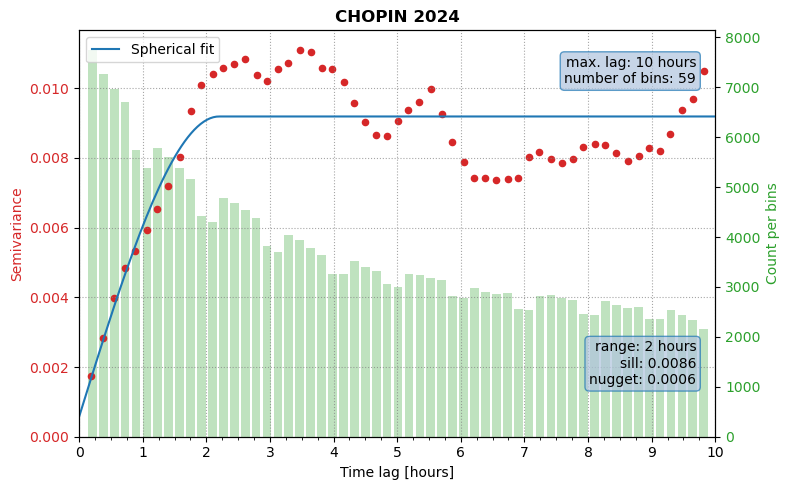

In [48]:
savefig = True

seltext = f"max. lag: {(max_time_diff)/60:.0f} hours\nnumber of bins: {nbin}"

fig, ax = plt.subplots(1, 1, figsize=[8, 5])

color0 = 'tab:red'
color1 = 'tab:blue'
color2 = 'tab:green'


unique_t = campaign_stat_dic['unique_t']
med_zdr = campaign_stat_dic['med_zdr']


bins_all = full_campaign_variogram_dic['bins']
bin_edges = full_campaign_variogram_dic['bin_edges']
sample_variogram_all = full_campaign_variogram_dic['sample_variogram']
num_points_all = full_campaign_variogram_dic['num_points']


# ----------------------------------------------------------------------------
if campaign_name == 'APRES3_1' or campaign_name == 'APRES3_2':
    marker_size = 10.
    bar_width = 0.8
elif campaign_name == 'VALAIS_2016_1':
    marker_size = 30.
    bar_width = 0.8
elif campaign_name == 'VALAIS_2016_2':
    marker_size = 6.
    bar_width = 0.6
else:
    marker_size = 20.
    bar_width = 0.8

# ----------------------------------------------------------------------------
if campaign_name == 'HYMEX_2013':
    f = spherical_plus_gaussian_variogram_scipy# two_sperical_variogram_scipy
    label = 'Spherical + Gaussian fit'
    text = f"range$_{0}$: {popt[0]/60:.0f} hours, sill$_{0}$: {popt[1]:.4f}\n"
    text += f"range$_{1}$: {popt[2]/60:.0f} hours, sill$_{1}$: {popt[3]:.4f}"
    text += f"nugget: {popt[4]:.4f}"
    max_x = 420.
elif campaign_name == 'PAYERNE_2014':
    f = two_sperical_variogram_scipy
    label = 'Spherical + Spherical fit'
    text = f"range$_{0}$: {popt[0]/60:.0f} hours, sill$_{0}$: {popt[1]:.4f}\n"
    text += f"range$_{1}$: {popt[2]/60:.0f} hours, sill$_{1}$: {popt[3]:.4f}"
    text += f"nugget: {popt[4]:.4f}"
    max_x = 420.
elif campaign_name == 'DAVOS_2014':
    f = spherical_variogram_scipy
    label = 'Spherical fit'
    text = f"range: {popt[0]/60:.0f} hours\nsill: {popt[1]:.4f}\n"
    text += f"nugget: {popt[2]:.4f}"
    max_x = 300.
elif campaign_name == 'VALAIS_2016_2':
    f = spherical_variogram_scipy
    label = 'Spherical fit'
    text = f"range: {popt[0]/60:.0f} hours\nsill: {popt[1]:.4f}\n"
    text += f"nugget: {popt[2]:.4f}"
    max_x = 800.
elif campaign_name == 'APRES3_1':
    f = spherical_plus_gaussian_variogram_scipy
    label = 'Spherical + Gaussian fit'
    text = f"range$_{0}$: {popt[0]/60:.0f} hours, sill$_{0}$: {popt[1]:.4f}\n"
    text += f"range$_{1}$: {popt[2]/60:.0f} hours, sill$_{1}$: {popt[3]:.4f}"
    text += f"nugget: {popt[4]:.4f}"
    max_x = 720.
elif campaign_name == 'APRES3_2':
    f = gaussian_variogram_scipy
    label = 'Gaussian fit'
    text = f"range: {popt[0]/60:.0f} hours\nsill: {popt[1]:.4f}\n"
    text += f"nugget: {popt[2]:.4f}"
    max_x = 720.
elif campaign_name == 'ICEGENESIS_2021':
    f = spherical_plus_gaussian_variogram_scipy# two_sperical_variogram_scipy
    label = 'Spherical + Gaussian fit'
    text = f"range$_{0}$: {popt[0]/60:.0f} hours, sill$_{0}$: {popt[1]:.4f}\n"
    text += f"range$_{1}$: {popt[2]/60:.0f} hours, sill$_{1}$: {popt[3]:.4f}"
    text += f"nugget: {popt[4]:.4f}"
    max_x = 840
elif campaign_name == 'APRES3_2':
    f = gaussian_variogram_scipy
    label = 'Gaussian fit'
    text = f"range: {popt[0]/60:.0f} hours\nsill: {popt[1]:.4f}\n"
    text += f"nugget: {popt[2]:.4f}"
    max_x = 720.
elif campaign_name == 'PLATO_2019':
    f = spherical_variogram_scipy
    label = 'Spherical fit'
    text = f"range: {popt[0]/60:.0f} hours\nsill: {popt[1]:.4f}\n"
    text += f"nugget: {popt[2]:.4f}"
    max_x = 480.
elif campaign_name == 'CHOPIN_2024':
    f = spherical_variogram_scipy
    label = 'Spherical fit'
    text = f"range: {popt[0]/60:.0f} hours\nsill: {popt[1]:.4f}\n"
    text += f"nugget: {popt[2]:.4f}"
    max_x = 600.
    
x_fit_plot = np.linspace(0., max_x, 200)
    
ax.scatter(bins_all, sample_variogram_all,
            s=marker_size, color=color0)

ax.plot(x_fit_plot, f(x_fit_plot, *popt), c=color1, label=label)


ax_twin = ax.twinx()
ax_twin.bar(bin_edges[:-1], num_points_all, width=bar_width*np.diff(bin_edges), align='center',
            color=color2, alpha=0.3, zorder=1)

ax.set_zorder(ax_twin.get_zorder()+1)
ax.patch.set_visible(False)

ax_twin.set_ylabel('Count per bins', color=color2)

ax_twin.tick_params(axis='y', labelcolor=color2)

ax.grid(ls=':', c='gray', alpha=0.7)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/60:.0f}"))
ax.set_xlabel('Time lag [hours]')
ax.set_ylabel('Semivariance', color=color0)
ax.tick_params(axis='y', labelcolor=color0)

ax.set_ylim((0., np.nanmax(sample_variogram_all)*1.05))

ax.set_title(campaign_name.replace('_', ' '), fontweight='bold')

legend_loc = ('upper left')
ax.legend(loc=legend_loc)

ax.text(0.97, 0.13, text, transform=ax.transAxes, horizontalalignment='right',
        bbox=dict(boxstyle='round', edgecolor='tab:blue', facecolor='lightsteelblue', alpha=0.7))

ax.text(0.97, 0.87, seltext, transform=ax.transAxes, horizontalalignment='right',
        bbox=dict(boxstyle='round', edgecolor='tab:blue', facecolor='lightsteelblue', alpha=0.7))

ax.set_xlim((0., max_x))
ax.xaxis.set_major_locator(MultipleLocator(60))
ax.xaxis.set_minor_locator(MultipleLocator(15))

plt.tight_layout()

if savefig:
    out_fig_fname = f'{IN_DIR}/variogram_calculated_{campaign_name}.pdf'
    plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

In [58]:
uk = kriging_dic['ordinary_kriging']
params = uk.variogram_model_parameters
print('range:  ', params[0])
print('sill: ', params[1])  
print('nugget:', params[2])


range:   132.0046610095378
sill:  0.008613628748231086
nugget: 0.0005773178588207851


## Kriging
### Adjust the variogram and function to be used for kriging, for each campaign (using previous cells)

In [49]:
t0 = full_campaign_variogram_dic['t0']

popt = full_campaign_variogram_fit_dic['popt']

X = (campaign_stat_dic['unique_t'] - t0)/60.
y = campaign_stat_dic['med_zdr']
    
valid = np.logical_and(np.isfinite(X), np.isfinite(y))

X = X[valid]
y = y[valid]

if campaign_name == 'HYMEX_2013':
    f = spherical_plus_gaussian_variogram # exponential_plus_gaussian_variogram
    variogram_name = 'Spherical + Gaussian'
elif campaign_name == 'PAYERNE_2014':
    f = two_sperical_variogram
    variogram_name = 'Spherical + Spherical'
elif campaign_name == 'DAVOS_2014':
    f = spherical_variogram
    variogram_name = 'Spherical'
elif campaign_name == 'VALAIS_2016_2':
    f = spherical_variogram
    variogram_name = 'Spherical'
elif campaign_name == 'APRES3_1':
    f = spherical_plus_gaussian_variogram
    variogram_name = 'Spherical + Gaussian'
elif campaign_name == 'APRES3_2':
    f = gaussian_variogram
    variogram_name = 'Gaussian'
elif campaign_name == 'ICEGENESIS_2021':
    f = spherical_plus_gaussian_variogram
    variogram_name = 'Spherical + Gaussian'
elif campaign_name == 'PLATO_2019':
    f = spherical_variogram
    variogram_name = 'Spherical'
elif campaign_name == 'CHOPIN_2024':
    f = spherical_variogram
    variogram_name = 'Spherical'
uk = OrdinaryKriging(X, np.zeros(X.shape), y, variogram_model='custom',
                        variogram_parameters=list(popt), variogram_function=f,  nlags=500)

kriging_dic = {'t0':t0,
                    'variogram_name':variogram_name,
                    'variogram_function':f,
                    'ordinary_kriging':uk}

In [52]:
print('y_std range:', y_std.min(), y_std.max())
print('2*y_std range:', (2*y_std).min(), (2*y_std).max())
print('y range:', y.min(), y.max())


y_std range: 0.0008114893401120358 0.009281485902639487
2*y_std range: 0.0016229786802240717 0.018562971805278973
y range: 0.45093002915382385 2.258288860321045


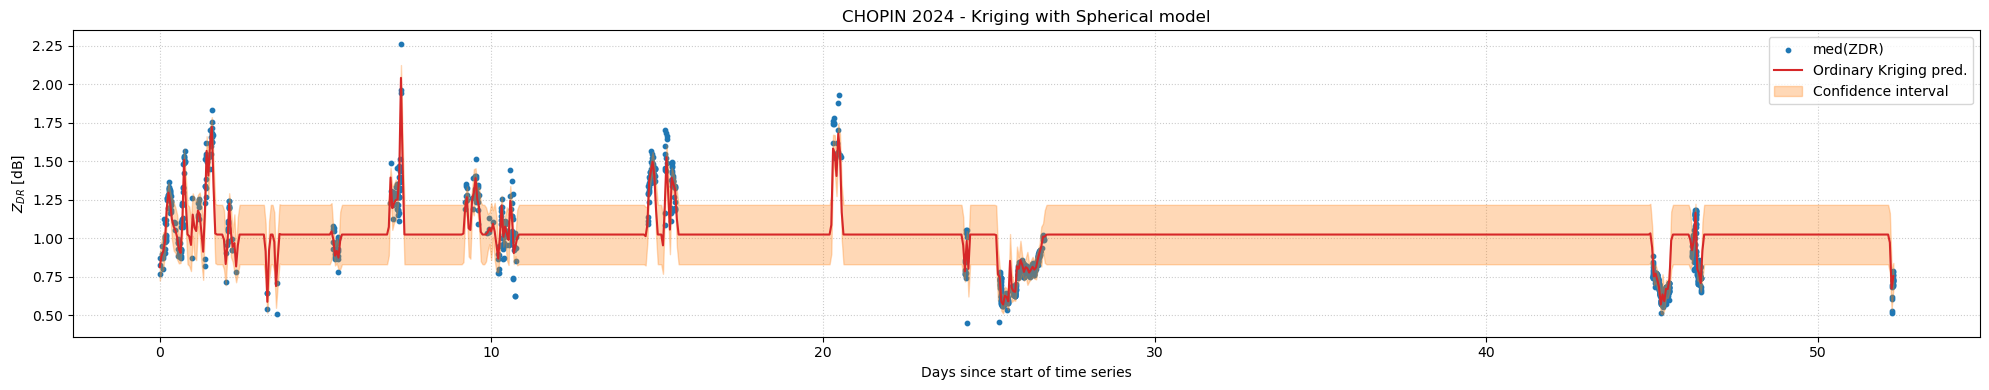

In [54]:
savefig = True

# Plotting
fig, ax = plt.subplots(1, 1, figsize=[20, 4])

color0 = 'tab:blue'
color1 = 'tab:red'
color2 = 'tab:orange'


ax.set_axisbelow(True)
ax.grid(ls=':', c='gray', alpha=0.4)

variogram_name = kriging_dic['variogram_name']
uk = kriging_dic['ordinary_kriging']
t0 = kriging_dic['t0']

X = (campaign_stat_dic['unique_t']-t0)/60.
y = campaign_stat_dic['med_zdr']
    
valid = np.logical_and(np.isfinite(X), np.isfinite(y))

X = X[valid]
y = y[valid]

X_pred = np.linspace(X.min()-5., X.max()+5., 1000)

y_pred, y_var = uk.execute("grid", X_pred, np.array([0.0]))
y_pred = np.squeeze(y_pred)
y_std = np.sqrt(np.squeeze(y_var))

if ((X_pred-X_pred[0])/60.)[-1] <= 48:
    plot_x_divider = 60.
    ax.set_xlabel("Hours since start of time series")
else:
    plot_x_divider = 60.*24.
    ax.set_xlabel("Days since start of time series")

ax.scatter((X-X_pred[0])/plot_x_divider, y, s=10, label="med(ZDR)", color=color0)
ax.plot((X_pred-X_pred[0])/plot_x_divider, y_pred, label="Ordinary Kriging pred.", color=color1)
ax.fill_between(
    (X_pred-X_pred[0])/plot_x_divider,
    y_pred - 2 * y_std,
    y_pred + 2 * y_std,
    alpha=0.3,
    label="Confidence interval",
    color=color2
)
ax.legend()
ax.set_ylabel(r"$Z_{DR}$ [dB]")
ax.set_title('%s - Kriging with %s model' % (campaign_name.replace('_', ' '), variogram_name))
    
    
plt.tight_layout()

if savefig:
    out_fig_fname = f'{IN_DIR}/full_Zdr_correction_{campaign_name}.pdf'
    plt.savefig(out_fig_fname, dpi=None, facecolor='w', edgecolor='w', format='pdf', orientation='portrait')

### Saving the Kriging dictionary - choose the name of the directory

In [30]:
kriging_dic

{'t0': 1701410816.0,
 'variogram_name': 'Spherical',
 'variogram_function': <function __main__.spherical_variogram(parameters, x)>,
 'ordinary_kriging': <pykrige.ok.OrdinaryKriging at 0x7e74e01a8250>}

In [31]:
# Loading the variogram fit parameters
popt = full_campaign_variogram_fit_dic['popt']

kriging_dic['popt'] = popt
KRIGING_SAVEDIR = '/t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606/'
if not os.path.exists(KRIGING_SAVEDIR):
    os.makedirs(KRIGING_SAVEDIR)
out_fname = os.path.join(KRIGING_SAVEDIR,'corrections_kriging_%s_20250430.pkl' % campaign_name)

pickle.dump(kriging_dic, open(out_fname, "wb"))
print('%s --> %s' % (campaign_name, out_fname))

CHOPIN_2024 --> /t5500/ltenas7/campaigns/CLEANCLOUD_CHOPIN_2024/MXPol/Zdr_calib_202606/corrections_kriging_CHOPIN_2024_20250430.pkl


# ========

# THE END

# ========